In [ ]:
# !pip install -q -U "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install -q --no-deps xformers "trl<0.9.0" peft accelerate bitsandbytes scikit-learn pandas tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.9/122.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 13.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from tqdm import tqdm
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
SEED = 3407
MAX_SEQ_LENGTH = 1024
DTYPE = None
LOAD_IN_4BIT = True

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['font.family'] = 'serif'

print(f"Environment set up. GPU: {torch.cuda.get_device_name(0)}")

Environment set up. GPU: Tesla T4


In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-7b-it-bnb-4bit",
    max_seq_length = MAX_SEQ_LENGTH,
    dtype = DTYPE,
    load_in_4bit = LOAD_IN_4BIT,
)

==((====))==  Unsloth 2026.1.3: Fast Gemma patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.57G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/154 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = SEED,
)

print("Архитектура Gemma-7B-LoRA инициализирована.")

Unsloth 2026.1.3 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Архитектура Gemma-7B-LoRA инициализирована.


In [ ]:
rusentitweet_train_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_train.csv'
rusentitweet_test_path = '/content/drive/MyDrive/Colab Notebooks/Third semester/Fine-Tuning/RuBert-Data/rusentitweet_test.csv'

train_df = pd.read_csv(rusentitweet_train_path)
test_df = pd.read_csv(rusentitweet_test_path)

alpaca_prompt = """Ниже приведен текст твита. Определи его тональность.
Варианты: positive, negative, neutral. Отвечай только одним словом.

### Твит:
{}

### Тональность:
{}"""

EOS_TOKEN = tokenizer.eos_token

In [ ]:
label2text = {0: "neutral", 1: "positive", 2: "negative", "speech_act": "neutral", "skip": "neutral"}

def formatting_prompts_func(examples):
    tweets = examples["text"]
    labels = examples["label"]
    texts = []
    for tweet, label in zip(tweets, labels):
        target = label2text.get(label, "neutral") if isinstance(label, int) else str(label).lower()
        if target not in ["positive", "negative", "neutral"]: target = "neutral"

        text = alpaca_prompt.format(tweet, target) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }

train_dataset = Dataset.from_pandas(train_df)
train_dataset = train_dataset.map(formatting_prompts_func, batched = True)

print("Пример подготовленных данных:", train_dataset[0]['text'])

Map:   0%|          | 0/10713 [00:00<?, ? examples/s]

Пример подготовленных данных: Ниже приведен текст твита. Определи его тональность.
Варианты: positive, negative, neutral. Отвечай только одним словом.

### Твит:
Помойму я вкрашилась в Чимина🤧 https://t.co/t2uZTS7NH2

### Тональность:
positive<eos>


In [ ]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 10,
        max_steps = 120,
        learning_rate = 2e-4,
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),
        logging_steps = 10,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = SEED,
        output_dir = "outputs",
    ),
)

Map (num_proc=2):   0%|          | 0/10713 [00:00<?, ? examples/s]

In [ ]:
print("Запуск SFT (Supervised Fine-Tuning)...")
trainer_stats = trainer.train()
print("Обучение завершено успешно.")

Запуск SFT (Supervised Fine-Tuning)...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,713 | Num Epochs = 1 | Total steps = 120
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 50,003,968 of 8,587,684,864 (0.58% trained)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss
10,13.218200
20,6.383600
30,4.427200
40,4.000500
50,3.370200
60,2.874900
70,2.433600
80,2.421900
90,2.417500
100,2.445500


Обучение завершено успешно.


In [ ]:
FastLanguageModel.for_inference(model)

predictions = []
ground_truth = []
inference_prompt = """Ниже приведен текст твита. Определи его тональность.

Варианты: positive, negative, neutral. Отвечай только одним словом.

### Твит:
{}

### Тональность:
"""

print(f"Обработка {len(test_df)} тестовых примеров...")

for index, row in tqdm(test_df.iterrows(), total=test_df.shape[0]):
    text = row['text']

    lbl = row['label']
    if isinstance(lbl, int): val = lbl
    else:
        m = {"neutral": 0, "positive": 1, "negative": 2}
        val = m.get(str(lbl).lower(), 0)
    ground_truth.append(val)

    inputs = tokenizer([inference_prompt.format(text)], return_tensors="pt").to("cuda")

    outputs = model.generate(**inputs, max_new_tokens=5, use_cache=True, pad_token_id=tokenizer.eos_token_id)
    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

    pred_text = decoded.split("### Тональность:")[-1].strip().lower()
    predictions.append(pred_text)

print("Инференс завершен.")

Обработка 2679 тестовых примеров...


100%|██████████| 2679/2679 [15:51<00:00,  2.81it/s]

Инференс завершен.


Failure Rate после Fine-Tuning: 0.00%


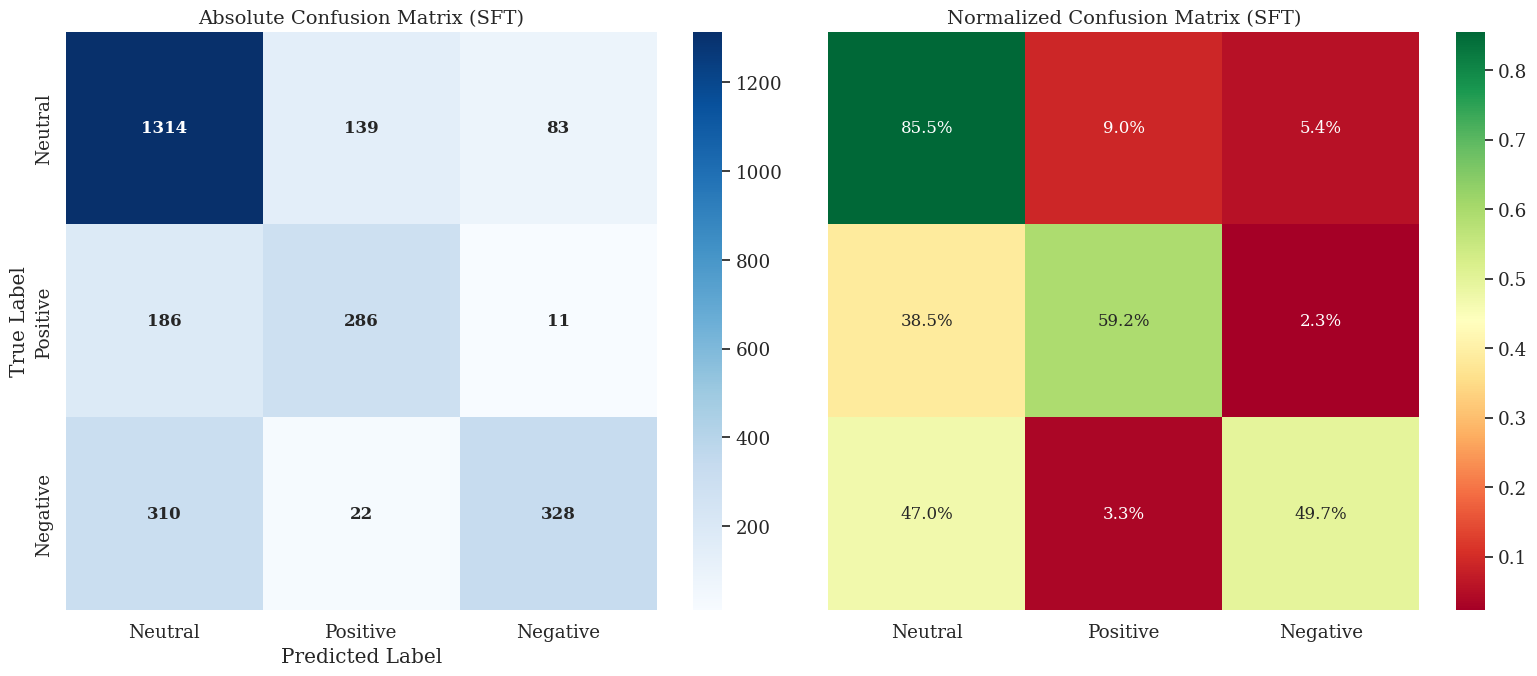


=== CLASSIFICATION REPORT (SFT) ===
              precision    recall  f1-score   support

     Neutral     0.7260    0.8555    0.7854      1536
    Positive     0.6398    0.5921    0.6151       483
    Negative     0.7773    0.4970    0.6063       660

    accuracy                         0.7197      2679
   macro avg     0.7143    0.6482    0.6689      2679
weighted avg     0.7231    0.7197    0.7106      2679



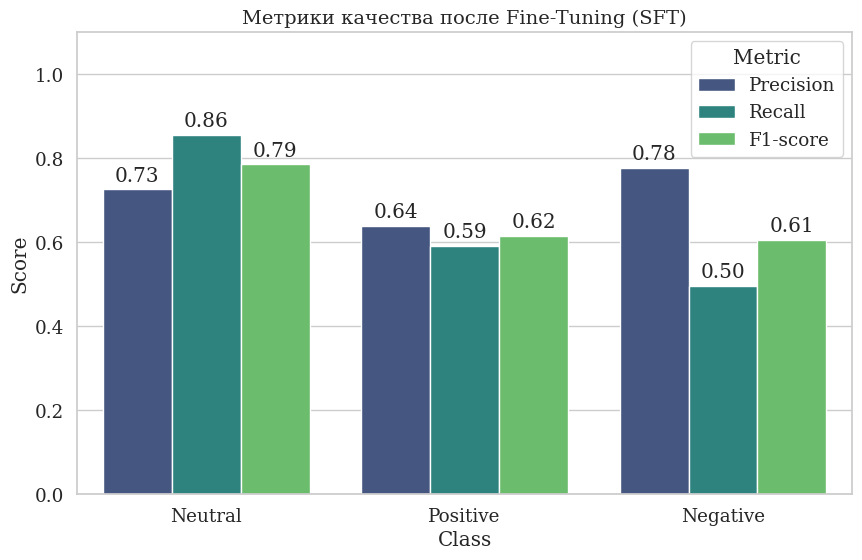

In [ ]:
pred_labels = []
parse_errors = 0

for p in predictions:
    if "posit" in p: pred_labels.append(1)
    elif "negat" in p: pred_labels.append(2)
    elif "neut" in p: pred_labels.append(0)
    else:
        pred_labels.append(0)
        parse_errors += 1

print(f"Failure Rate после Fine-Tuning: {parse_errors/len(predictions)*100:.2f}%")

def plot_results(y_true, y_pred):
    classes = ["Neutral", "Positive", "Negative"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 12, "weight": "bold"})
    axes[0].set_title('Absolute Confusion Matrix (SFT)', fontsize=14)
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='RdYlGn', ax=axes[1],
                xticklabels=classes, yticklabels=classes, annot_kws={"size": 12})
    axes[1].set_title('Normalized Confusion Matrix (SFT)', fontsize=14)
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.savefig('gemma_sft_confusion_matrix.png', dpi=300)
    plt.show()

    print("\n=== CLASSIFICATION REPORT (SFT) ===")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

plot_results(ground_truth, pred_labels)

report = classification_report(ground_truth, pred_labels, target_names=["Neutral", "Positive", "Negative"], output_dict=True)
df_metrics = pd.DataFrame([
    {"Class": cls, "Metric": m, "Score": report[cls][m.lower()]}
    for cls in ["Neutral", "Positive", "Negative"]
    for m in ["Precision", "Recall", "F1-score"]
])

plt.figure(figsize=(10, 6))
chart = sns.barplot(data=df_metrics, x="Class", y="Score", hue="Metric", palette="viridis")
plt.title("Метрики качества после Fine-Tuning (SFT)", fontsize=14)
plt.ylim(0, 1.1)
for container in chart.containers:
    chart.bar_label(container, fmt='%.2f', padding=3)
plt.savefig('gemma_sft_metrics.png', dpi=300)
plt.show()